# Flag collection: training

Train Q-learning and SARSA independently, then inspect their saved plots and optional recordings. Parameters are editable below. Training starts only when `RUN_TRAINING=True`; running this notebook with its default flag creates no experiment artifacts. See [the section guide](README.md) for the task and output conventions.

In [1]:
from pathlib import Path
import sys
ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "rl_project").is_dir())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from IPython.display import Image, Markdown, Video, display
from rl_project.runtime import video_sort_key
from rl_project.discrete import validate_algorithms
ALGORITHM_LABELS = {"qlearning": "Q-learning", "sarsa": "SARSA"}
from Grid_flag.grid_flag_env import GridFlagEnv
from Grid_flag.grid_flag_agent import GridFlagAgent

## Configuration

The agent collects five flags on a 10×10 grid. Collecting the final flag terminates immediately. The 100-step external cutoff stops the rollout while retaining the value bootstrap. Actions are 0=stay, 1=up, 2=down, 3=left, 4=right.

`config.json` is written automatically inside each new run as a snapshot of the settings used. Edit this notebook, not that saved snapshot. Shortening the episode budget does not automatically accelerate the exploration schedule.

In [2]:
ALGORITHMS = ("qlearning", "sarsa")  # Select both, or e.g. ("sarsa",).
RUN_TRAINING = True
SEED = 0
NUM_EPISODES = 5000  # Budget for each selected algorithm.
MAX_ENV_STEPS = None  # Optional per-algorithm step budget; use NUM_EPISODES=None for steps only.
OUTPUT_ROOT = ROOT / "artifacts"
RECORD_EVERY = 500  # Set None to disable demonstration recordings.
LOG_EVERY = 500
SHOW_PROGRESS = True

# One common task for both algorithms.
ENV_KWARGS = {
    "grid_size": (10, 10),
    "max_step": 100,
    "agent_start": (5, 5),
    "flag_value": 10,
    "flag_cells": [(1, 2), (3, 7), (6, 1), (7, 8), (9, 4)],
    "render_mode": None,
}

# Independent algorithm settings: changing one does not change the other.
AGENT_KWARGS = {
    "qlearning": {
        "learning_rate": .1,
        "discount_factor": .95,
        "initial_epsilon": 1.,
        "epsilon_decay": .95 / 5000,
        "final_epsilon": .05,
    },
    "sarsa": {
        "learning_rate": .1,
        "discount_factor": .95,
        "initial_epsilon": 1.,
        "epsilon_decay": .95 / 5000,
        "final_epsilon": .05,
    },
}

## Train

Each selected algorithm gets a fresh agent and a separate run directory. Checkpoints and incremental CSV metrics are saved before plotting. Q-learning uses a greedy backup; SARSA executes the same next action that was sampled for its backup.

The live total progress bar stays below summaries of each `LOG_EVERY` completed episodes, including a final partial block. Summary and recording labels start at episode 0; the total bar and CSV count completed episodes from 1.

In [3]:
agents = {}
results = {}
selected_algorithms = validate_algorithms(ALGORITHMS)
if RUN_TRAINING:
    for algorithm in selected_algorithms:
        display(Markdown(f"### {ALGORITHM_LABELS[algorithm]} training"))
        env = GridFlagEnv(**ENV_KWARGS)
        try:
            agent = GridFlagAgent(env, seed=SEED, environment="flag", **AGENT_KWARGS[algorithm])
            result = agent.train(
                NUM_EPISODES, algorithm=algorithm, max_env_steps=MAX_ENV_STEPS,
                output_root=OUTPUT_ROOT, record_every=RECORD_EVERY,
                log_every=LOG_EVERY, show_progress=SHOW_PROGRESS,
            )
            agents[algorithm] = agent
            results[algorithm] = result
            print(f"Saved run: {result.run_dir}")
        finally:
            env.close()
else:
    print("Training not run. Set RUN_TRAINING=True to start fresh runs; no checkpoint was loaded.")

### Q-learning training

Saved run: /Users/anthonymc/Desktop/NAML_project/artifacts/flag/qlearning/20260913T085943978379Z_seed0_85399cae


### SARSA training

Saved run: /Users/anthonymc/Desktop/NAML_project/artifacts/flag/sarsa/20260913T085951982917Z_seed0_d34cfb8b


## Inspect plots and recordings

Reward bands show rolling mean ± two rolling standard deviations within one run. Outcomes show rolling success rate and flags collected; binary success/collision indicators are omitted. TD error and epsilon are learning diagnostics.

With `RECORD_EVERY=500`, separate greedy demonstrations run after training episodes 0, 500, 1000, and so on, producing `episode_0.mp4`, `episode_500.mp4`, etc. Episode 0 is the first completed training episode. Videos are capped at 300 frames and 800 pixels wide; the demonstration still runs to the actual episode boundary.

### Q-learning outputs

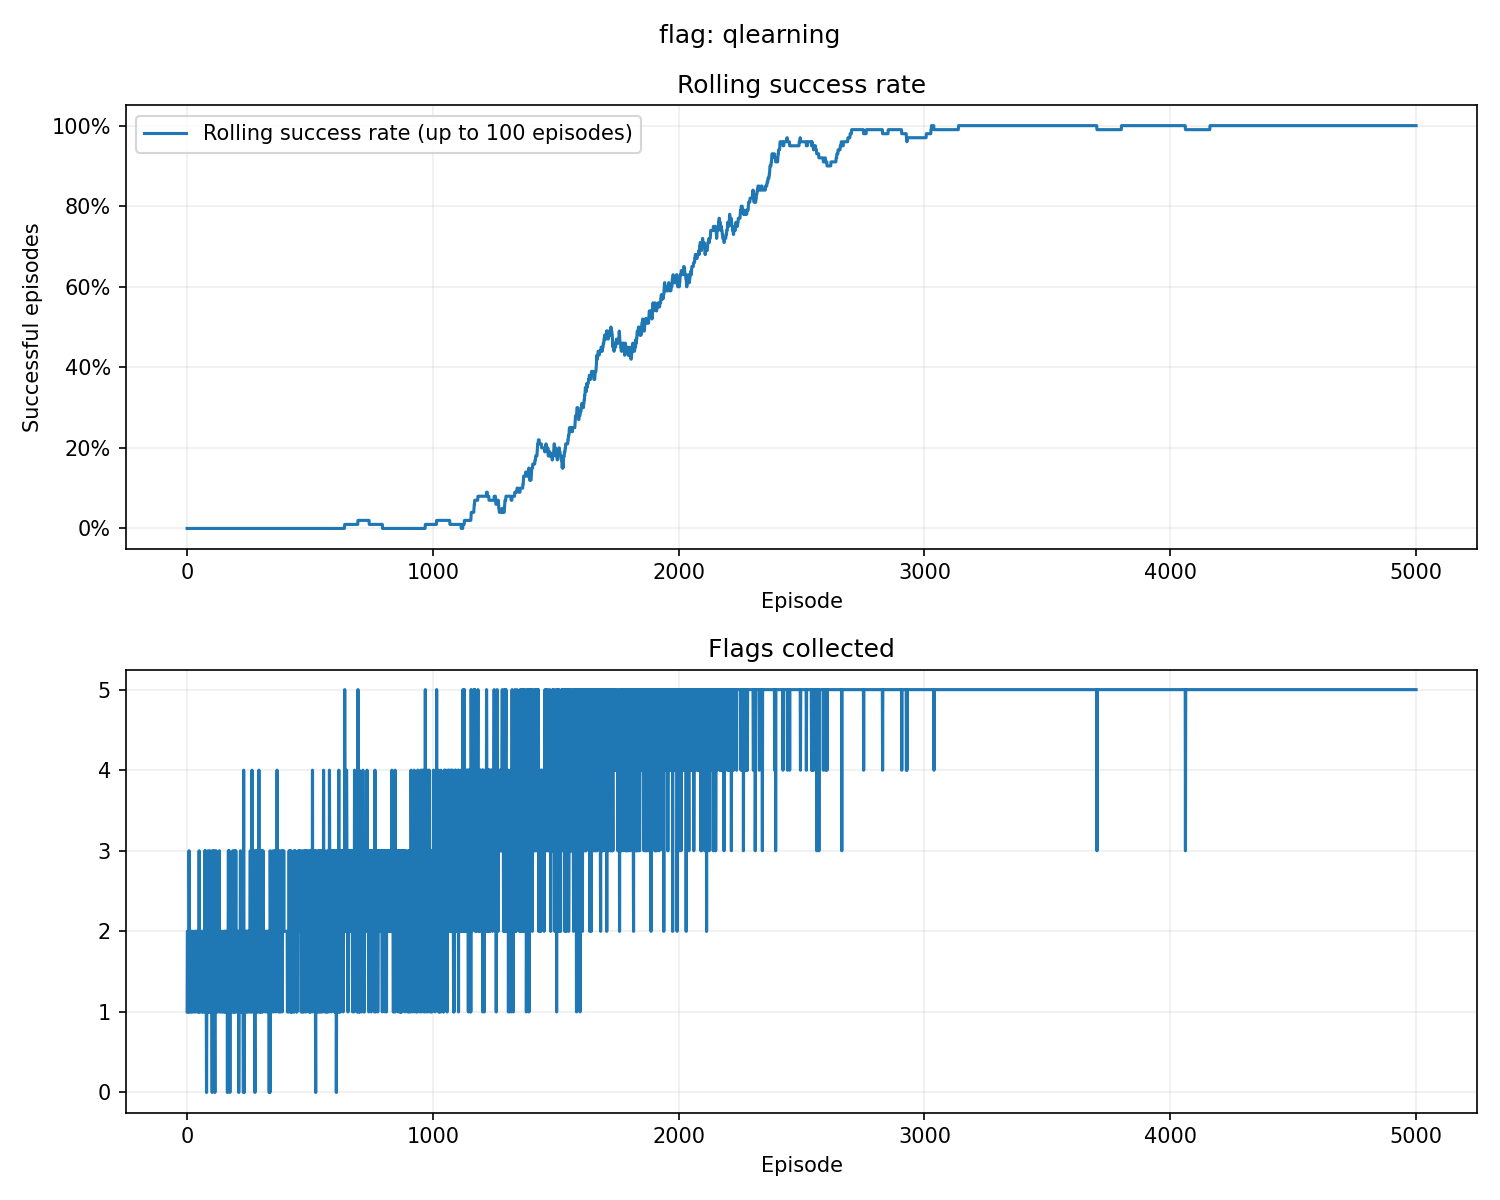

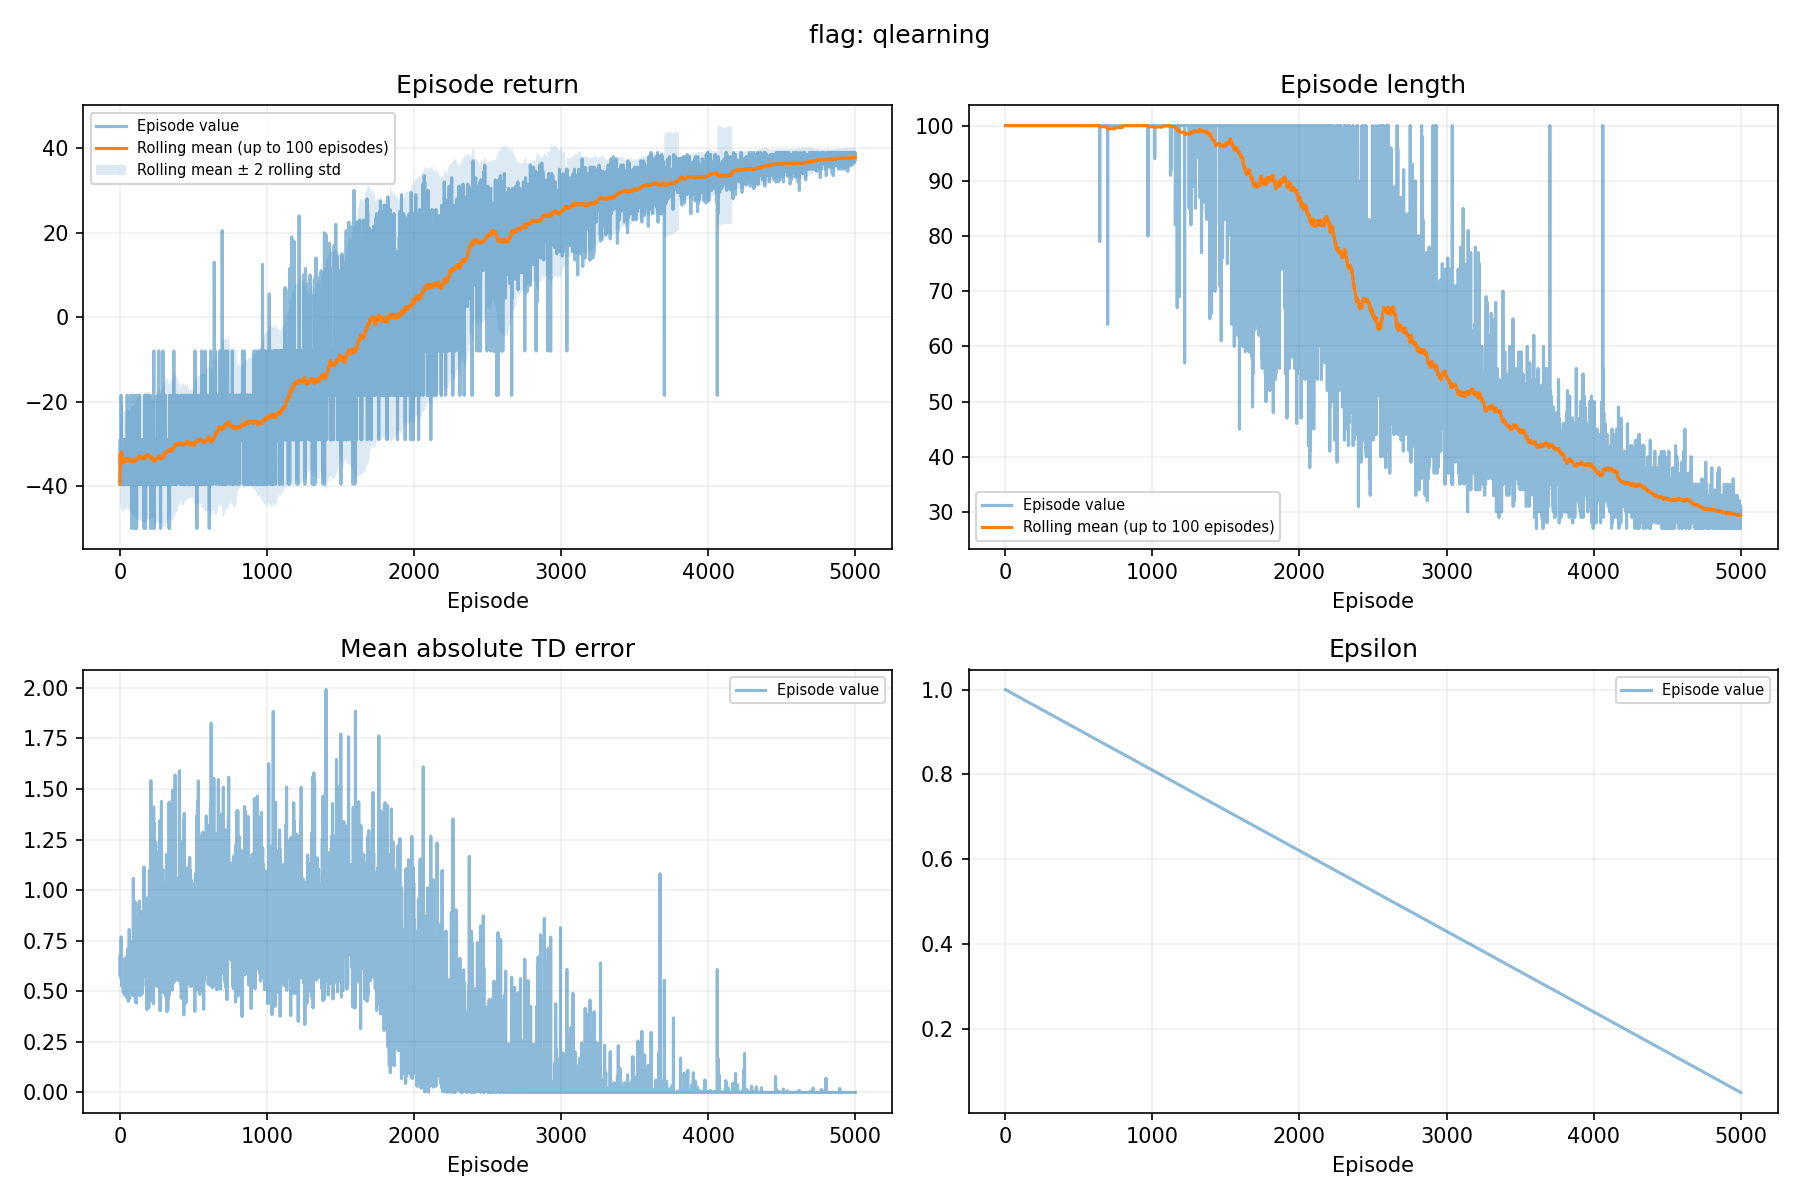

**episode_0.mp4**

**episode_500.mp4**

**episode_1000.mp4**

**episode_1500.mp4**

**episode_2000.mp4**

...

**episode_3000.mp4**

**episode_3500.mp4**

**episode_4000.mp4**

**episode_4500.mp4**

### SARSA outputs

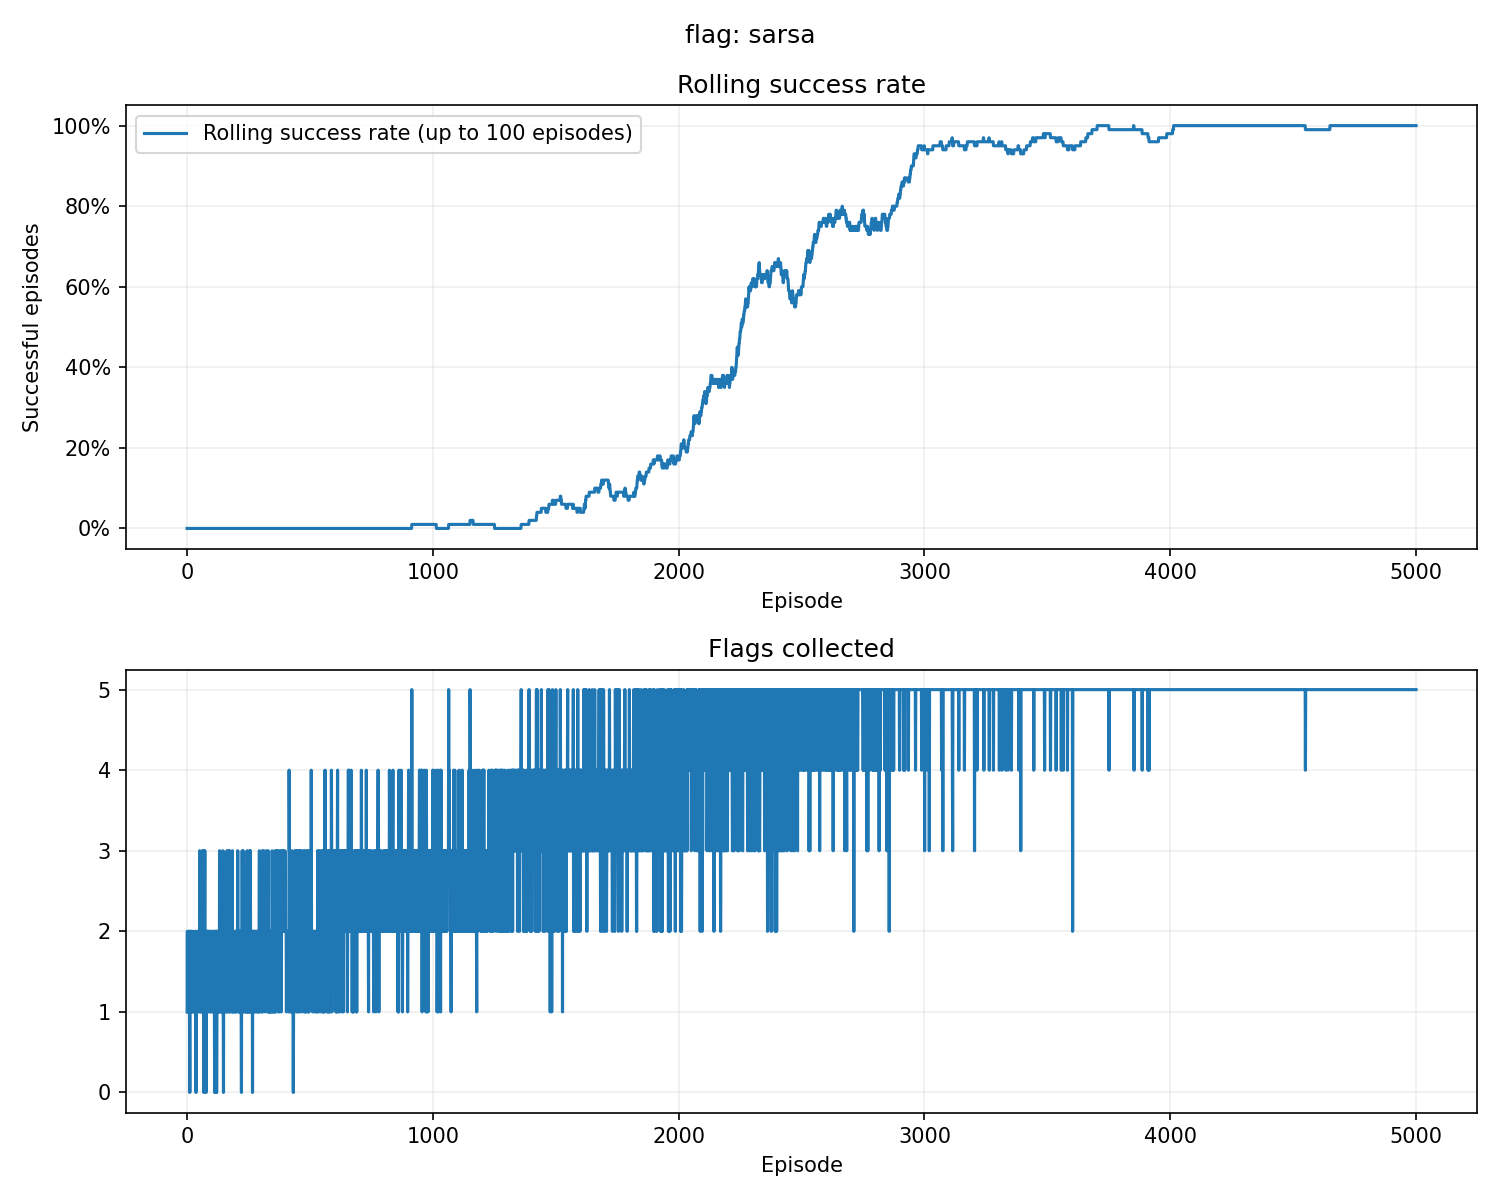

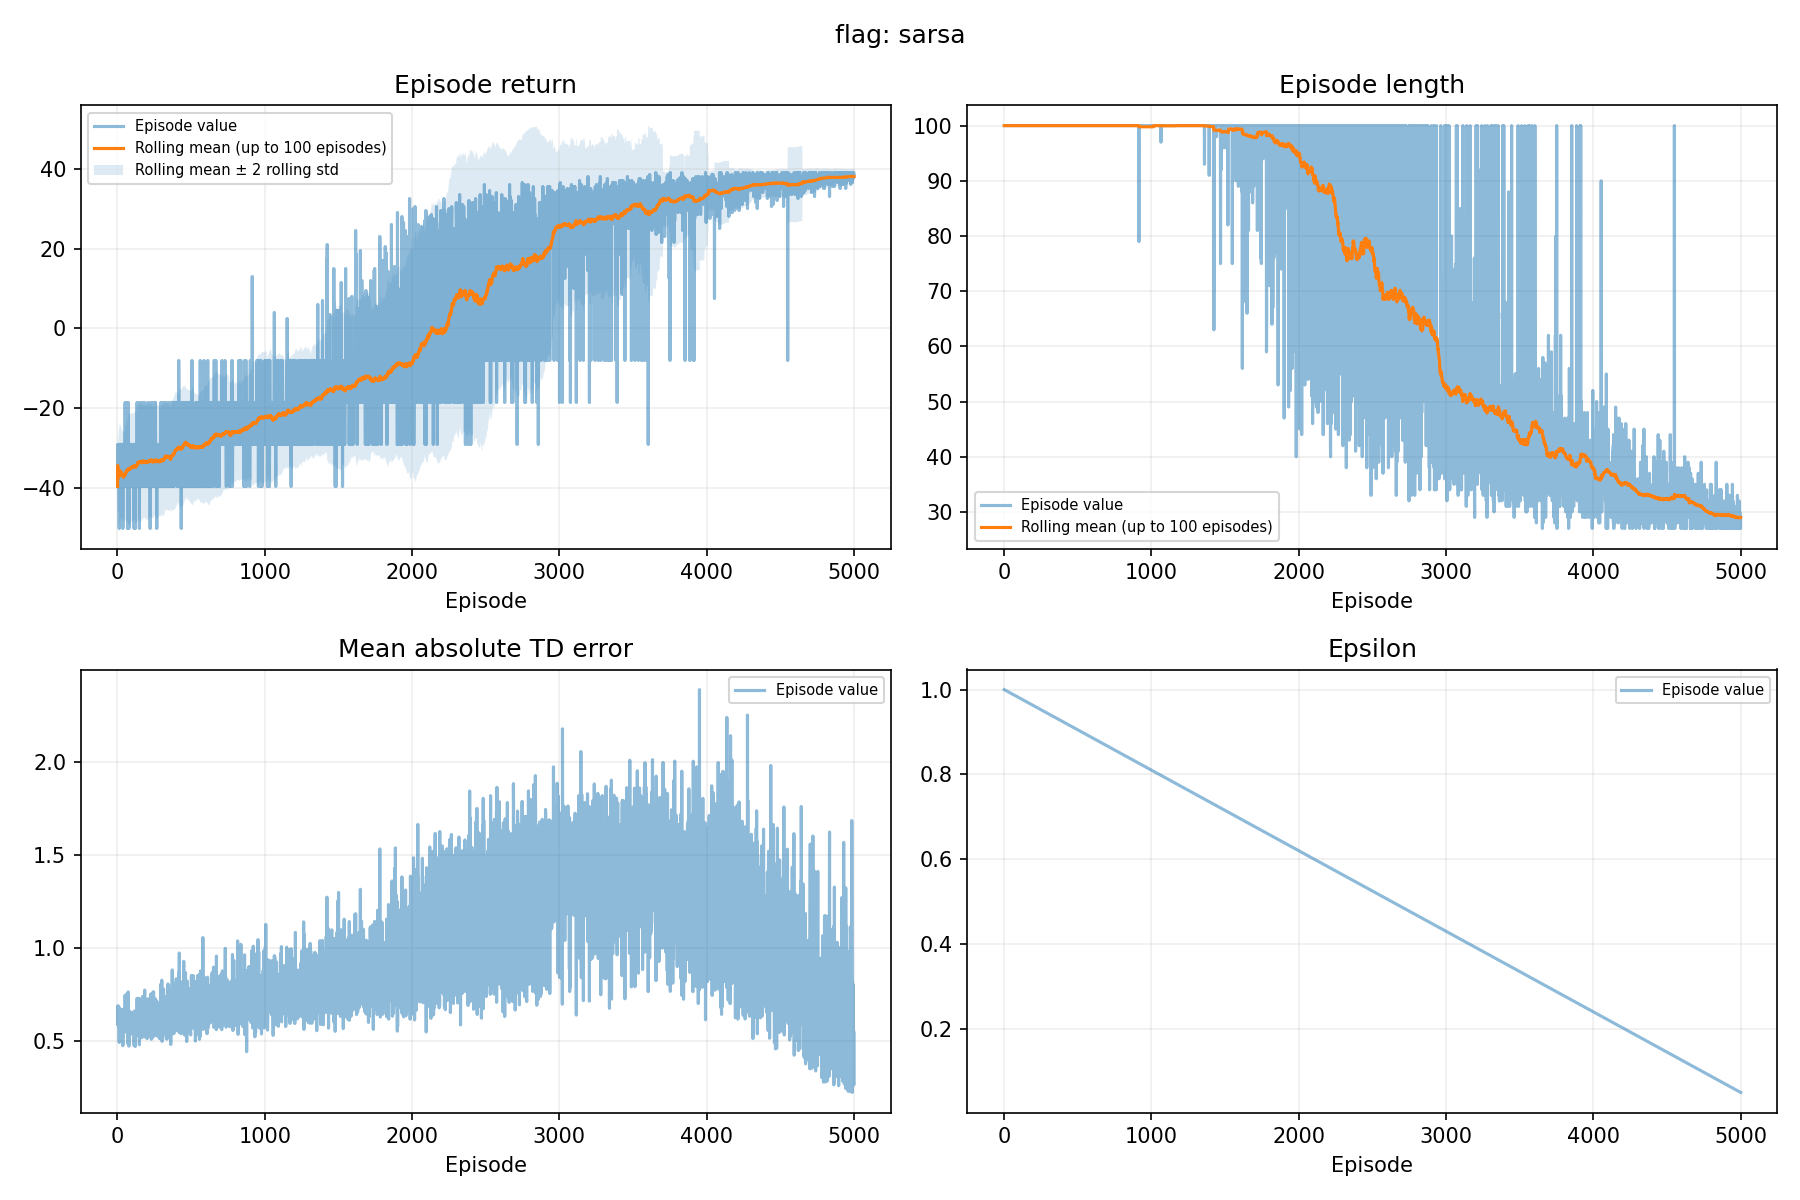

**episode_0.mp4**

**episode_500.mp4**

**episode_1000.mp4**

**episode_1500.mp4**

**episode_2000.mp4**

**episode_2500.mp4**

**episode_3000.mp4**

**episode_3500.mp4**

**episode_4000.mp4**

**episode_4500.mp4**

In [4]:
for algorithm, result in results.items():
    display(Markdown(f"### {ALGORITHM_LABELS[algorithm]} outputs"))
    for path in sorted((result.run_dir / "plots").glob("*.png")):
        display(Image(filename=str(path)))
    for path in sorted((result.run_dir / "videos/training").glob("*.mp4"), key=video_sort_key):
        display(Markdown(f"**{path.name}**"))
        display(Video(filename=str(path), embed=True))

## Evaluation and report export

Open [eval_grid_flag.ipynb](eval_grid_flag.ipynb) to evaluate selected checkpoints greedily and save presentation recordings.

For the report, review the completed runs and copy Q-learning `plots/training_curves.png` as `GridFlag_training_curves.png`, and the SARSA equivalent as `GridFlag_training_curves_SARSA.png`. Update the matching report analysis using the saved metrics. [The report figure inventory](../Report/figures/README.md) identifies the pending slots. This notebook does not replace report evidence automatically.